# QEpy MD + Wavefunction Diagnostics (Minimal Example)

This notebook runs a short Andersen MD trajectory with QEpy and logs:
- potential/kinetic energy per atom
- KS eigenvalues at a selected k-point
- a two-band KS gap
- same-band wavefunction overlap magnitude/phase between consecutive MD steps

The goal is to show how to combine ASE MD control with QEpy electronic diagnostics.

## User inputs

Set all run controls here:
- `N_STEPS`, `DT_FS`, `TEMPERATURE_K`, `ANDERSEN_PROB`
- `BANDS` and `KPT` for electronic diagnostics
- `INPUTFILE` and output location

For a quick demo, keep `N_STEPS` small.

In [1]:
from pathlib import Path

# --- run parameters ---
# Keep all user-facing knobs in one place.
WORKDIR = Path("./")
OUTDIR = WORKDIR / "."
N_STEPS = 20
# Track the chemically meaningful frontier set for stretched-H2O:
#   1,2 = σ(O-H) bonding pair    3 = O lone pair (control)
#   4   = σ*_OH (LUMO)           5,6 = next virtuals that mix with σ*_OH
BANDS = (2, 3, 4)
KPT = 0         # k-point index
TEMPERATURE_K = 300.0
DT_FS = 0.5
ANDERSEN_PROB = 0.02
USE_MPI = False
SEED = 2020

In [1]:
# --- optional pip installs (normally leave collapsed / do not run) ---
!pip install qepy
!pip install ase
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Imports and runtime dependencies

This notebook uses:
- `ASE` for MD and trajectory handling
- `QEpyCalculator` for forces/energies/electronic data
- `NumPy` for array math
- `matplotlib` for plotting

In [3]:
import csv
import itertools
import os
from pathlib import Path

import numpy as np
from ase import Atoms, units
from ase.io.trajectory import Trajectory
from ase.md.andersen import Andersen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from qepy.calculator import QEpyCalculator

## Build atoms, calculator, and MD engine

This block:
1. enters the working directory
2. creates the QEpy calculator from the QE input file
3. attaches calculator to ASE atoms
4. initializes velocities at target temperature
5. creates Andersen dynamics
6. allocates buffers for time-series data

The QE input below (`qe_options`) defines a stretched-H₂O system: one O–H bond pulled out to ~1.5 Å from its ~0.97 Å equilibrium, so the MD run below has interesting bond dynamics and orbital reorganization to track.

In [4]:
# QE options copied from h2o_in_aimd.in
# Starting geometry: one O-H bond stretched to ~1.5 Å (equilibrium ~0.97 Å).
# H1 is displaced along the O→H1 unit vector from the equilibrium position.
qe_options = {
    "&control": {
        "calculation": "'scf'",
        "restart_mode": "'from_scratch'",
        "disk_io": "'none'",
        "pseudo_dir": "'./data/'",
    },
    "&system": {
        "ibrav": 0,
        "nat": 3,
        "nbnd": 10,
        "ntyp": 2,
        "ecutwfc": 40,
        "occupations": "'smearing'",
        "degauss": 0.001,
        "smearing": "'gaussian'",
        "nosym": True,
    },
    "&electrons": {
        "electron_maxstep": 100,
        "conv_thr": 1e-6,
        "mixing_beta": 0.7,
        "diago_thr_init": 1.0e-4,
        "diago_david_ndim": 2,
    },
    "atomic_species": [
        "O  15.999   O_ONCV_PBE-1.2.upf",
        "H  1.008    H_ONCV_PBE-1.2.upf",
    ],
    # qepy's input writer iterates over each section's value, so use an empty
    # list for gamma — the section name "k_points gamma" already encodes it.
    "k_points gamma": [],
    "cell_parameters angstrom": [
        "8.00000000000000 0.00000000000000 0.00000000000000",
        "0.00000000000000 8.00000000000000 0.00000000000000",
        "0.00000000000000 0.00000000000000 8.00000000000000",
    ],
    # H1 stretched: O-H1 bond = 1.50 Å (was 0.969 Å equilibrium). H2 unchanged.
    "atomic_positions angstrom": [
        "O 3.0000000000 3.0000000000 3.2859286667",
        "H 3.0000000000 4.1819930000 2.3624456667",
        "H 3.0000000000 2.2367610000 2.6896196667",
    ],
}

qe_options

{'&control': {'calculation': "'scf'",
  'restart_mode': "'from_scratch'",
  'disk_io': "'none'",
  'pseudo_dir': "'./data/'"},
 '&system': {'ibrav': 0,
  'nat': 3,
  'nbnd': 10,
  'ntyp': 2,
  'ecutwfc': 40,
  'occupations': "'smearing'",
  'degauss': 0.001,
  'smearing': "'gaussian'",
  'nosym': True},
 '&electrons': {'electron_maxstep': 100,
  'conv_thr': 1e-06,
  'mixing_beta': 0.7,
  'diago_thr_init': 0.0001,
  'diago_david_ndim': 2},
 'atomic_species': ['O  15.999   O_ONCV_PBE-1.2.upf',
  'H  1.008    H_ONCV_PBE-1.2.upf'],
 'k_points gamma': [],
 'cell_parameters angstrom': ['8.00000000000000 0.00000000000000 0.00000000000000',
  '0.00000000000000 8.00000000000000 0.00000000000000',
  '0.00000000000000 0.00000000000000 8.00000000000000'],
 'atomic_positions angstrom': ['O 3.0000000000 3.0000000000 3.2859286667',
  'H 3.0000000000 4.1819930000 2.3624456667',
  'H 3.0000000000 2.2367610000 2.6896196667']}

In [5]:
os.chdir(WORKDIR)
OUTDIR.mkdir(parents=True, exist_ok=True)

# Deterministic thermostat randomness for reproducible demo runs.
np.random.seed(SEED)
comm = None
log_path = OUTDIR / "tmp.out"

# Build ASE Atoms from qe_options (cell + symbols + positions).
cell = np.array(
    [[float(x) for x in row.split()] for row in qe_options["cell_parameters angstrom"]],
    dtype=float,
)
position_lines = qe_options["atomic_positions angstrom"]
symbols = [line.split()[0] for line in position_lines]
positions = np.array([[float(x) for x in line.split()[1:4]] for line in position_lines], dtype=float)
atoms = Atoms(symbols=symbols, positions=positions, cell=cell, pbc=True)

# Build QEpy calculator directly from qe_options.
calc = QEpyCalculator(comm=comm, qe_options=qe_options, logfile=str(log_path))
atoms.calc = calc

# Initialize velocities and MD integrator/thermostat.
MaxwellBoltzmannDistribution(atoms, temperature_K=TEMPERATURE_K, force_temp=True)
dyn = Andersen(atoms, DT_FS * units.fs, temperature_K=TEMPERATURE_K, andersen_prob=ANDERSEN_PROB,)

# Normalize requested bands once (sorted + unique).
bands = tuple(sorted(set(BANDS)))
kpt = KPT

# Index lookup for the O and H atoms — used to track bond lengths per step.
o_idx = symbols.index("O")
h_idx = [i for i, s in enumerate(symbols) if s == "H"]

# Buffers for time series and wavefunction-derived observables.
steps_md = []
epot_pa = []
ekin_pa = []
temp_k = []
oh_d1 = []   # O - H1 bond length (Å), the stretched bond at t=0
oh_d2 = []   # O - H2 bond length (Å), the spectator bond at t=0
wf_rows = []
psi_prev = {b: None for b in bands}   # previous-step wavefunctions (consecutive overlap)
psi_ref = {b: None for b in bands}    # t=0 reference wavefunctions (time-based overlap)
md_step = {"i": 0}

## Overlap metric definition

`overlap(prev, cur)` computes same-band overlap between consecutive MD steps:
- magnitude: electronic-state continuity indicator
- phase: gauge/phase evolution indicator

The overlap is normalized by wavefunction norms.

In [6]:
def overlap(prev, cur):
    """Return overlap magnitude and phase between two same-band wavefunctions."""
    if prev is None:
        return np.nan, np.nan
    ov_n = np.sum(np.conjugate(prev) * cur)
    n_prev = np.sum(np.conjugate(prev) * prev).real
    n_cur = np.sum(np.conjugate(cur) * cur).real
    wv_nrm = np.sqrt(n_prev * n_cur)
    ov = ov_n / wv_nrm
    return float(np.abs(ov)), float(np.angle(ov))

## Time-based overlaps (vs the t=0 reference state)

For a stretched-bond AIMD it's informative to track wavefunction overlaps with respect to the **initial (t=0)** state rather than only consecutive steps. Two diagnostics:

- `time_overlap(ref, cur)` — same-band overlap |⟨ψₙ(0)|ψₙ(t)⟩|. Smooth decay = adiabatic evolution; sudden drops = state mixing or crossing.
- `overlap_matrix(refs, curs)` — full band×band overlap matrix between the t=0 reference set and the current set. **Off-diagonal entries growing while a diagonal entry collapses ⇒ a state crossing.** Especially relevant here as the O–H bond elongates and frontier orbitals (lone pair / σ_OH / σ*_OH) reorganize.

In [7]:
def overlap_matrix(refs, curs):
    """|<ref_i | cur_j>| matrix built from the existing overlap() helper.
    Off-diagonal growth (with a diagonal collapse) flags state mixing/crossings."""
    n = len(refs)
    M = np.full((n, n), np.nan)
    for i, r in enumerate(refs):
        for j, c in enumerate(curs):
            mag, _ = overlap(r, c)
            M[i, j] = mag
    return M

## Per-step data collection callback

`on_step()` is called every MD step and records:
- per-atom energies
- selected eigenvalues and optional two-band gap
- same-band overlap metrics using current vs previous wavefunctions

In [8]:
def wf_step():
    # Called by ASE every MD step.
    a = dyn.atoms
    s = md_step["i"]; md_step["i"] += 1
    n = len(a)

    # Store basic thermodynamic observables per atom.
    steps_md.append(s)
    epot_pa.append(float(a.get_potential_energy() / n))
    ekin_pa.append(float(a.get_kinetic_energy() / n))

    # Track both O-H bond lengths in Å (mic=True respects the periodic box).
    oh_d1.append(float(a.get_distance(o_idx, h_idx[0], mic=True)))
    oh_d2.append(float(a.get_distance(o_idx, h_idx[1], mic=True)))

    # Only root rank writes wavefunction/eigenvalue diagnostics.
    if not getattr(a.calc, "is_root", True):
        return

    # KS eigenvalues at the selected k-point.
    eps = np.asarray(calc.get_eigenvalues(kpt=kpt), dtype=float)
    row = {"step": s, **{f"eval_b{b}": float(eps[b]) for b in bands}}

    # Emit every pairwise gap among the tracked bands so the plot cell can
    # choose which to display (HOMO–LUMO, σ→σ*, virtual–virtual, etc.).
    for b0, b1 in itertools.combinations(sorted(bands), 2):
        row[f"gap_b{b1}_b{b0}"] = float(eps[b1] - eps[b0])

    # Wavefunctions are returned in the same order as `bands`.
    psi_list = calc.get_wave_function(kpt=kpt, band=bands)
    psi_cur = {}
    for b, psi_b in zip(bands, psi_list):
        psi_b = np.asarray(psi_b, dtype=np.complex128).ravel()
        psi_cur[b] = psi_b

        # Consecutive-step overlap (existing diagnostic).
        mag, ph = overlap(psi_prev[b], psi_b)
        row[f"ovl_abs_b{b}"] = mag
        row[f"ovl_phase_b{b}"] = ph

        # Time-based overlap vs the t=0 reference state.
        mag_t, ph_t = overlap(psi_ref[b], psi_b)
        row[f"tovl_abs_b{b}"] = mag_t
        row[f"tovl_phase_b{b}"] = ph_t

        psi_prev[b] = psi_b

    # Cross-band overlap matrix vs t=0 — flatten upper-triangle including diagonal.
    if all(psi_ref[b] is not None for b in bands):
        M = overlap_matrix([psi_ref[b] for b in bands], [psi_cur[b] for b in bands])
        for i, bi in enumerate(bands):
            for j, bj in enumerate(bands):
                row[f"tmat_b{bi}_b{bj}"] = float(M[i, j])

    # On the first recorded step, freeze the reference wavefunctions.
    if all(psi_ref[b] is None for b in bands):
        for b in bands:
            psi_ref[b] = psi_cur[b]

    wf_rows.append(row)

## Run dynamics and write outputs

This block runs MD and writes:
- `md.traj` trajectory
- `md_observables.csv` (step, potential/kinetic energy per atom)
- `wf_overlap.csv` (eigenvalues, gap, overlap magnitude/phase)

In [9]:

# Run MD and record atomic trajectory + custom observables each step.
traj_path = OUTDIR / "md.traj"
traj = Trajectory(str(traj_path), "w", atoms)
dyn.attach(traj.write, interval=1)
dyn.attach(wf_step, interval=1)
dyn.run(N_STEPS)
traj.close()

# Save per-step energies.
csv_md = OUTDIR / "md_observables.csv"
with open(csv_md, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["step", "epot_Ha_per_atom", "ekin_Ha_per_atom"])
    for i, s in enumerate(steps_md):
        w.writerow([s, epot_pa[i], ekin_pa[i]])

# Save eigenvalue/gap/overlap diagnostics.
# Fieldnames are the union over all rows: the t=0 row lacks tmat_* keys
# (they only appear once psi_ref is populated), so later rows would otherwise
# contain "extra" fields and crash DictWriter.
csv_wf = OUTDIR / "wf_overlap.csv"
if wf_rows:
    all_keys = set()
    for r in wf_rows:
        all_keys.update(r.keys())
    all_keys.discard("step")
    fieldnames = ["step"] + sorted(all_keys)
    with open(csv_wf, "w", newline="") as f:
        dw = csv.DictWriter(f, fieldnames=fieldnames, restval="")
        dw.writeheader()
        dw.writerows(wf_rows)

print("Wrote:", csv_md)
print("Wrote:", csv_wf)
print("Wrote:", traj_path)
print("Wrote:", log_path)

Wrote: md_observables.csv
Wrote: wf_overlap.csv
Wrote: md.traj
Wrote: tmp.out


## Energy-conservation sanity check

Print per-step potential/kinetic/total energy per atom. Under Andersen dynamics, total energy isn't exactly conserved (the thermostat randomly rescales velocities) — the reported standard deviation is a quick sanity check that it's only drifting by the expected thermostat noise, not diverging.

In [10]:
# Total energy per atom = potential + kinetic (both already per-atom).
# Under NVE this is conserved; under Andersen it drifts only when the thermostat
# rescales velocities, so the std is a useful sanity check on the run.
etot_pa = [pe + ke for pe, ke in zip(epot_pa, ekin_pa)]

print(f"{'step':>6}  {'E_pot/atom (Ha)':>18}  {'E_kin/atom (Ha)':>18}  {'E_tot/atom (Ha)':>18}")
for s, pe, ke, te in zip(steps_md, epot_pa, ekin_pa, etot_pa):
    print(f"{s:>6d}  {pe:>18.8f}  {ke:>18.8f}  {te:>18.8f}")

print(f"\nE_tot/atom: mean = {np.mean(etot_pa):.8f} Ha,  std = {np.std(etot_pa):.2e} Ha")

  step     E_pot/atom (Ha)     E_kin/atom (Ha)     E_tot/atom (Ha)
     0       -153.59585578          0.03877799       -153.55707779
     1       -153.61039777          0.02727579       -153.58312199
     2       -153.60006780          0.00521492       -153.59485287
     3       -153.61669730          0.02181906       -153.59487823
     4       -153.66005662          0.06514034       -153.59491627
     5       -153.72983122          0.13486528       -153.59496594
     6       -153.82574472          0.23073880       -153.59500591
     7       -153.94772566          0.35267224       -153.59505342
     8       -154.09526832          0.50011250       -153.59515582
     9       -154.25994989          0.66163233       -153.59831755
    10       -154.39627118          0.78848808       -153.60778310
    11       -154.38383096          0.76295789       -153.62087307
    12       -154.23944601          0.36829083       -153.87115517
    13       -154.08477959          0.22602718       -153.8587

## Plot diagnostics

Panels show:
- potential energy per atom
- kinetic energy per atom
- KS gap for selected band pair
- same-band overlap magnitude for tracked bands

Interpretation tip: overlap values near 1 indicate smooth electronic-state evolution between steps.

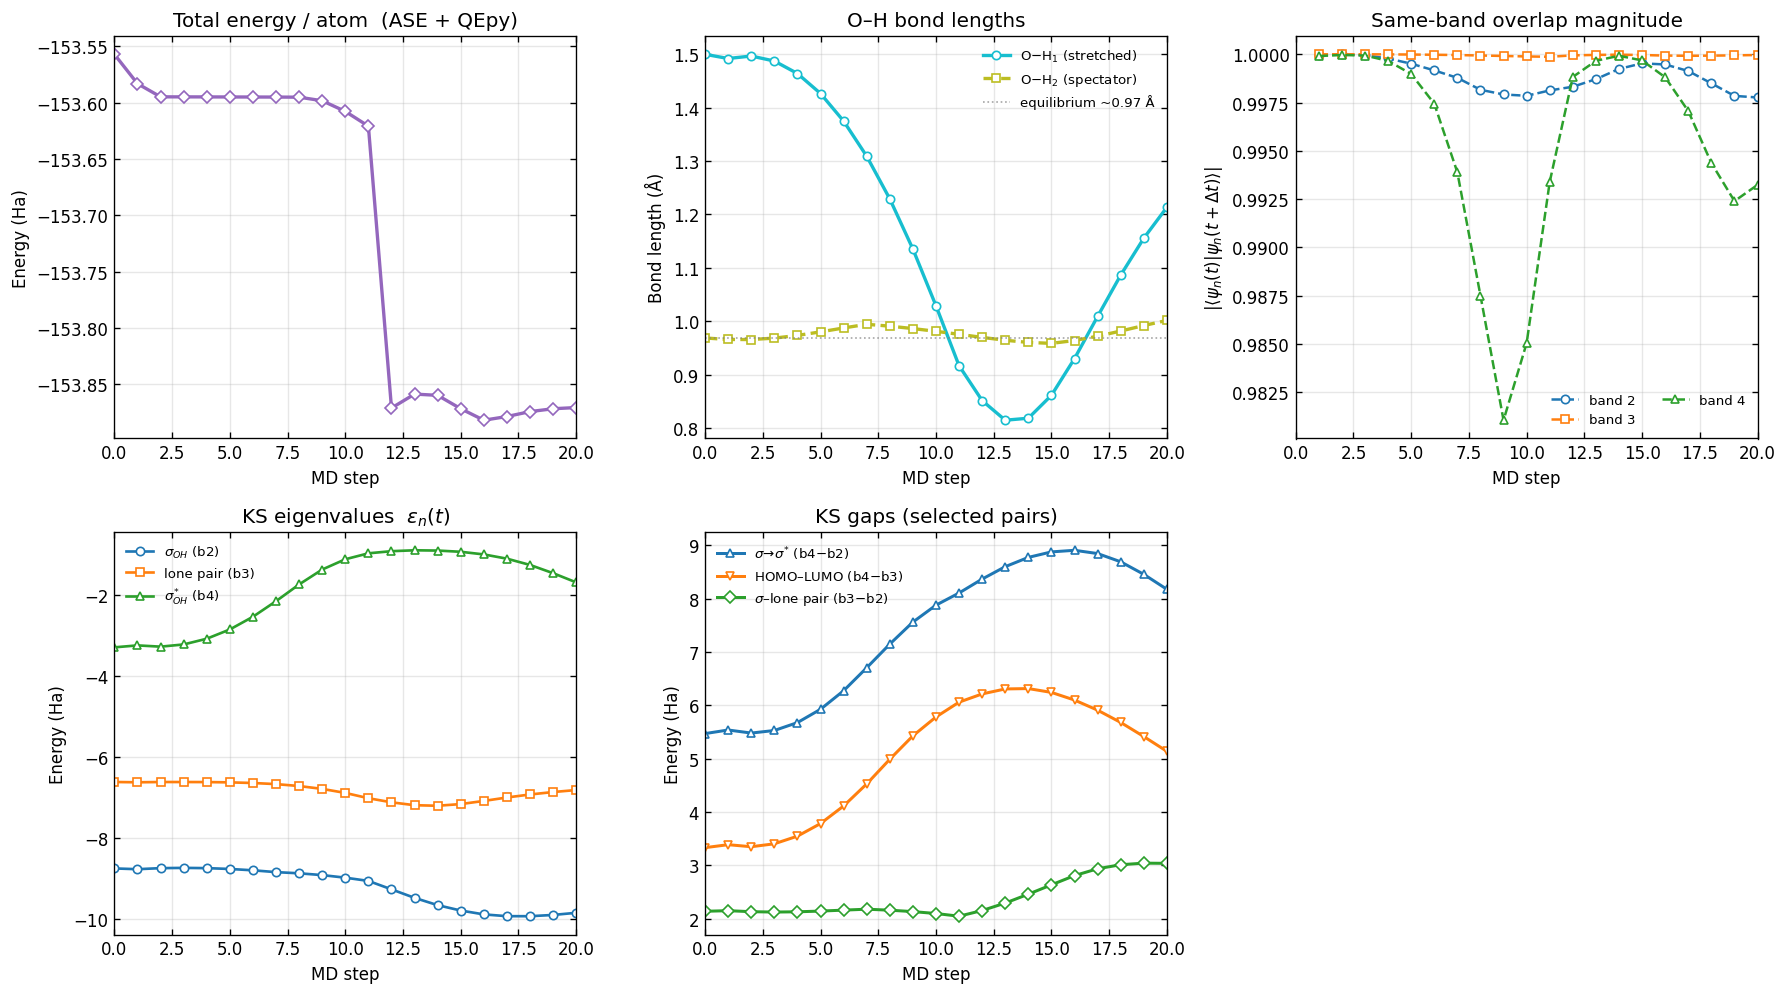

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Convert collected lists to arrays for plotting.
sw = np.asarray(steps_md, dtype=float)
ep = np.asarray(epot_pa, dtype=float)
ek = np.asarray(ekin_pa, dtype=float)
et = ep + ek

d1 = np.asarray(oh_d1, dtype=float)
d2 = np.asarray(oh_d2, dtype=float)

swf = np.asarray([r["step"] for r in wf_rows], dtype=float)

plt.rcParams.update({
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})

# 2x3 layout — 5 storytelling panels + 1 hidden:
#   Row 1: workflow + geometry + same-band overlap
#   Row 2: individual eigenvalues + KS gaps + (hidden)
fig, axs = plt.subplots(2, 3, figsize=(15, 8.4), dpi=120)

# --- (0,0) Workflow: total E per atom ------------------------------------
axs[0, 0].plot(sw, et, lw=2, color="tab:purple",
               linestyle="-", marker="D", markersize=5, markerfacecolor="white")
axs[0, 0].set_title("Total energy / atom  (ASE + QEpy)")
axs[0, 0].set_xlabel("MD step"); axs[0, 0].set_ylabel("Energy (Ha)")
axs[0, 0].grid(alpha=0.3)

# --- (0,1) Case-study geometry: O-H bond lengths -------------------------
axs[0, 1].plot(sw, d1, lw=2, color="tab:cyan",
               linestyle="-", marker="o", markersize=5, markerfacecolor="white",
               label=r"O$-$H$_1$ (stretched)")
axs[0, 1].plot(sw, d2, lw=2, color="tab:olive",
               linestyle="--", marker="s", markersize=5, markerfacecolor="white",
               label=r"O$-$H$_2$ (spectator)")
axs[0, 1].axhline(0.969, color="grey", lw=1, linestyle=":", alpha=0.7,
                  label="equilibrium ~0.97 Å")
axs[0, 1].set_title("O–H bond lengths")
axs[0, 1].set_xlabel("MD step"); axs[0, 1].set_ylabel("Bond length (Å)")
axs[0, 1].grid(alpha=0.3)
axs[0, 1].legend(frameon=False, fontsize=8)

# --- (0,2) Electronic response: same-band overlap ------------------------
ovl_markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
for b, mk in zip(bands, ovl_markers):
    y = np.asarray([float(r.get(f"ovl_abs_b{b}", np.nan)) for r in wf_rows], dtype=float)
    axs[0, 2].plot(swf, y, lw=1.5, linestyle="--", marker=mk, markersize=5,
                   markerfacecolor="white", label=f"band {b}")
axs[0, 2].set_title("Same-band overlap magnitude")
axs[0, 2].set_xlabel("MD step")
axs[0, 2].set_ylabel(r"$|\langle \psi_n(t)|\psi_n(t+\Delta t)\rangle|$")
axs[0, 2].grid(alpha=0.3)
axs[0, 2].legend(frameon=False, fontsize=8, ncol=2)

# --- (1,0) Individual KS eigenvalues ε_n(t) ------------------------------
eig_labels = {2: r"$\sigma_{OH}$ (b2)", 3: "lone pair (b3)", 4: r"$\sigma^{*}_{OH}$ (b4)"}
for b, mk in zip(bands, ovl_markers):
    y = np.asarray([float(r.get(f"eval_b{b}", np.nan)) for r in wf_rows], dtype=float)
    axs[1, 0].plot(swf, y, lw=1.6, linestyle="-", marker=mk, markersize=5,
                   markerfacecolor="white", label=eig_labels.get(b, f"band {b}"))
axs[1, 0].set_title("KS eigenvalues  $\\varepsilon_n(t)$")
axs[1, 0].set_xlabel("MD step"); axs[1, 0].set_ylabel("Energy (Ha)")
axs[1, 0].grid(alpha=0.3)
axs[1, 0].legend(frameon=False, fontsize=8)

# --- (1,1) KS gaps among the tracked bands -------------------------------
gap_picks = [
    (4, 2, r"$\sigma\!\to\!\sigma^{*}$ (b4$-$b2)"),
    (4, 3, "HOMO–LUMO (b4$-$b3)"),
    (3, 2, r"$\sigma$–lone pair (b3$-$b2)"),
]
gap_picks = [(hi, lo, lbl) for hi, lo, lbl in gap_picks if hi in bands and lo in bands]
gap_markers = ["^", "v", "D"]
for (hi, lo, lbl), mk in zip(gap_picks, gap_markers):
    key = f"gap_b{hi}_b{lo}"
    y = np.asarray([float(r.get(key, np.nan)) for r in wf_rows], dtype=float)
    axs[1, 1].plot(swf, y, lw=1.8, linestyle="-", marker=mk, markersize=5,
                   markerfacecolor="white", label=lbl)
axs[1, 1].set_title("KS gaps (selected pairs)")
axs[1, 1].set_xlabel("MD step"); axs[1, 1].set_ylabel("Energy (Ha)")
axs[1, 1].grid(alpha=0.3)
axs[1, 1].legend(frameon=False, fontsize=8)

# --- (1,2) hidden --------------------------------------------------------
axs[1, 2].set_visible(False)

# Clamp x-axis to data endpoints.
x_hi_md = float(sw.max())
x_hi_wf = float(swf.max()) if swf.size else x_hi_md
for ax in (axs[0, 0], axs[0, 1]):
    ax.set_xlim(0.0, x_hi_md)
for ax in (axs[0, 2], axs[1, 0], axs[1, 1]):
    ax.set_xlim(0.0, x_hi_wf)

for ax in axs.flat:
    if ax.get_visible():
        ax.tick_params(which="both", direction="in", top=True, right=True)

plt.tight_layout()
plt.savefig("md_diagnostics.pdf", bbox_inches="tight")
plt.show()